# Обучение без учителя

Практическая работа по снижению размерности и поиску выбросов

## Подготовка датасета

In [52]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

%matplotlib inline
plt.style.use("seaborn-v0_8-whitegrid")

In [53]:
data_path = Path(r"D:\ProjectAI\ai_brief-main\cirrhosis_preprocessed.csv")
dataset = pd.read_csv(data_path)

print(f"Форма датасета: {dataset.shape}")
print("Список столбцов:")
print(dataset.columns.tolist())
display(dataset.head())

Форма датасета: (312, 21)
Список столбцов:
['ID', 'N_Days', 'Status', 'Drug', 'Age', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage', 'Age_years']


,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,...,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Age_years
0,1,400,2.0,0.0,21464,0.0,1.0,1.0,1.0,2.0,...,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0,58.805479
1,2,4500,0.0,0.0,20617,0.0,0.0,1.0,1.0,0.0,...,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0,56.484932
2,3,1012,2.0,0.0,25594,1.0,0.0,0.0,0.0,1.0,...,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0,70.120548
3,4,1925,2.0,0.0,19994,0.0,0.0,1.0,1.0,1.0,...,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0,54.778082
4,5,1504,1.0,1.0,13918,0.0,0.0,1.0,1.0,0.0,...,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0,38.131507


In [54]:
status_series = dataset["Status"].astype(int)
status_values = sorted(status_series.unique())
label_names = {value: f"Status {value}" for value in status_values}

print("Распределение по значениям Status:")
display(status_series.value_counts().sort_index().rename("count").to_frame())
print("Типы данных:")
display(dataset.dtypes.rename("dtype").to_frame())

Распределение по значениям Status:


,count
Status,
0,168
1,19
2,125


Типы данных:


,dtype
ID,int64
N_Days,int64
Status,float64
Drug,float64
Age,int64
Sex,float64
Ascites,float64
Hepatomegaly,float64
Spiders,float64
Edema,float64


In [55]:
from sklearn.preprocessing import StandardScaler

feature_cols = [col for col in dataset.columns if col not in ["ID", "Status"]]
X_df = dataset[feature_cols].copy()
y = status_series.to_numpy()

scaler = StandardScaler()
X = scaler.fit_transform(X_df)

print(f"В анализе участвует {len(feature_cols)} признаков")
print(feature_cols)
print("Размер матрицы признаков после стандартизации:", X.shape)
display(X_df.describe().T[["mean", "std", "min", "max"]].round(2))

В анализе участвует 19 признаков
['N_Days', 'Drug', 'Age', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage', 'Age_years']
Размер матрицы признаков после стандартизации: (312, 19)


,mean,std,min,max
N_Days,2006.36,1123.28,41.00,4556.00
Drug,0.49,0.50,0.00,1.00
Age,18269.44,3864.81,9598.00,28650.00
Sex,0.12,0.32,0.00,1.00
Ascites,0.08,0.27,0.00,1.00
Hepatomegaly,0.51,0.50,0.00,1.00
Spiders,0.29,0.45,0.00,1.00
Edema,0.22,0.55,0.00,2.00
Bilirubin,3.26,4.53,0.30,28.00
Cholesterol,364.12,221.92,120.00,1775.00


Главная ячейка следующей ячейки - оформить красивые и единообразные графики для результатов, которые считаются в следующих ячейках

In [56]:
def plot_embedding(embedding, labels, title, xlabel="z1", ylabel="z2"):
    plt.figure(figsize=(10, 6))
    colors = plt.cm.Set2(np.linspace(0, 1, len(status_values)))
    for color, cls in zip(colors, status_values):
        mask = labels == cls
        plt.scatter(
            embedding[mask, 0],
            embedding[mask, 1],
            s=55,
            alpha=0.85,
            color=color,
            edgecolor="k",
            linewidth=0.3,
            label=label_names[cls],
        )
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_clusters_projection(projection, labels, title):
    plt.figure(figsize=(10, 6))
    unique_labels = sorted(set(labels))
    cluster_labels = [label for label in unique_labels if label != -1]
    palette = plt.cm.tab10(np.linspace(0, 1, max(1, len(cluster_labels))))
    color_index = 0

    for cluster_id in unique_labels:
        mask = labels == cluster_id
        if cluster_id == -1:
            plt.scatter(
                projection[mask, 0],
                projection[mask, 1],
                c="black",
                marker="x",
                s=70,
                linewidth=1.0,
                label="Noise (-1)",
            )
        else:
            plt.scatter(
                projection[mask, 0],
                projection[mask, 1],
                c=[palette[color_index]],
                s=55,
                alpha=0.85,
                edgecolor="k",
                linewidth=0.3,
                label=f"Cluster {cluster_id}",
            )
            color_index += 1

    plt.title(title)
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_anomalies_projection(projection, anomaly_mask, title):
    plt.figure(figsize=(10, 6))
    plt.scatter(
        projection[~anomaly_mask, 0],
        projection[~anomaly_mask, 1],
        c="lightgray",
        s=45,
        alpha=0.75,
        label="Обычные наблюдения",
    )
    plt.scatter(
        projection[anomaly_mask, 0],
        projection[anomaly_mask, 1],
        c="red",
        marker="x",
        s=80,
        linewidth=1.2,
        label="Потенциальные выбросы",
    )
    plt.title(title)
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Понижение размерности 
На этом датасете признаки имеют очень разные масштабы, поэтому перед применением методов я сделал стандартизацию. Колонка Status не участвует в обучении преобразований и применяется только для окраски точек и внешней оценки результатов

# Линейные методы уменьшения размерности (Linear Dimensionality Reduction Methods)

Рассмотрим два линейных подхода: PCA и ICA

### Метод главных компонентов (Principal Component Analysis, PCA)

In [57]:
from sklearn.decomposition import PCA

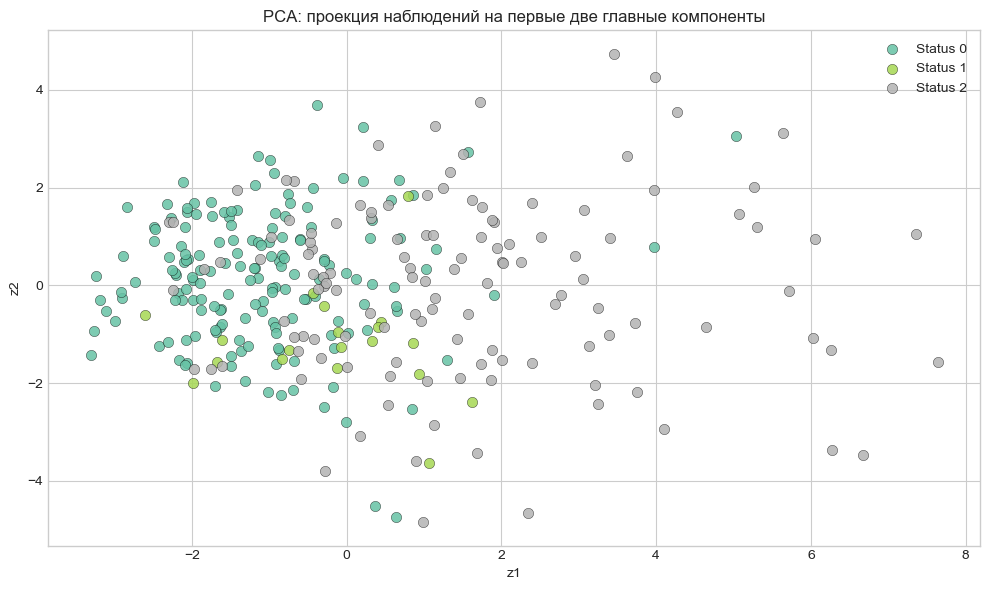

In [58]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

plot_embedding(
    X_pca,
    y,
    "PCA: проекция наблюдений на первые две главные компоненты",
)

,component,explained_variance_ratio,cumulative_ratio
0,PC1,0.2248,0.2248
1,PC2,0.1292,0.3540


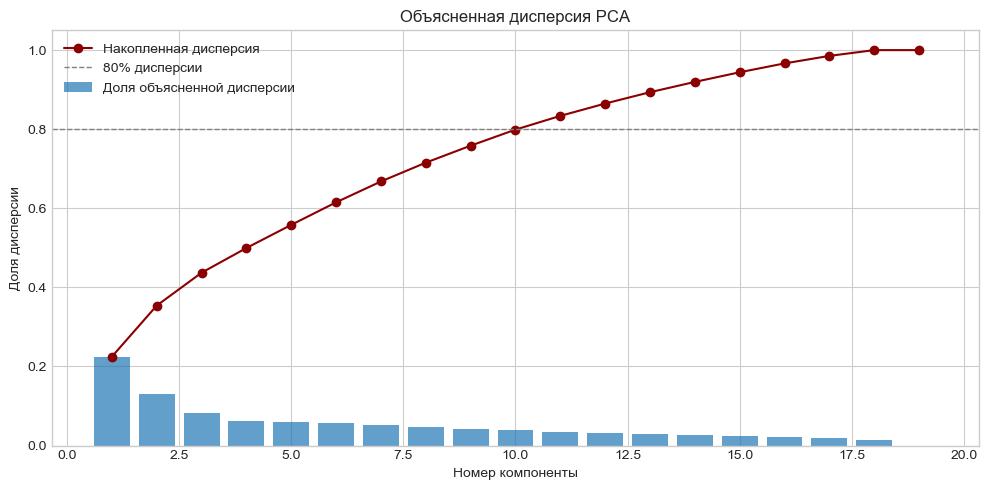

In [59]:
explained_variance = pd.DataFrame({
    "component": ["PC1", "PC2"],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_ratio": np.cumsum(pca.explained_variance_ratio_),
})

display(explained_variance.round(4))

full_pca = PCA(random_state=42).fit(X)
cumulative_variance = np.cumsum(full_pca.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.bar(
    range(1, len(full_pca.explained_variance_ratio_) + 1),
    full_pca.explained_variance_ratio_,
    alpha=0.7,
    label="Доля объясненной дисперсии",
)
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o",
    color="darkred",
    label="Накопленная дисперсия",
)
plt.axhline(0.8, color="gray", linestyle="--", linewidth=1, label="80% дисперсии")
plt.xlabel("Номер компоненты")
plt.ylabel("Доля дисперсии")
plt.title("Объясненная дисперсия PCA")
plt.legend()
plt.tight_layout()
plt.show()

### Независимый анализ компонентов (Independent Component Analysis, ICA)

In [60]:
from sklearn.decomposition import FastICA

fast_ica = FastICA(n_components=2, random_state=42, max_iter=5000, whiten="unit-variance")
X_ica = fast_ica.fit_transform(X)

Количество итераций ICA: 5


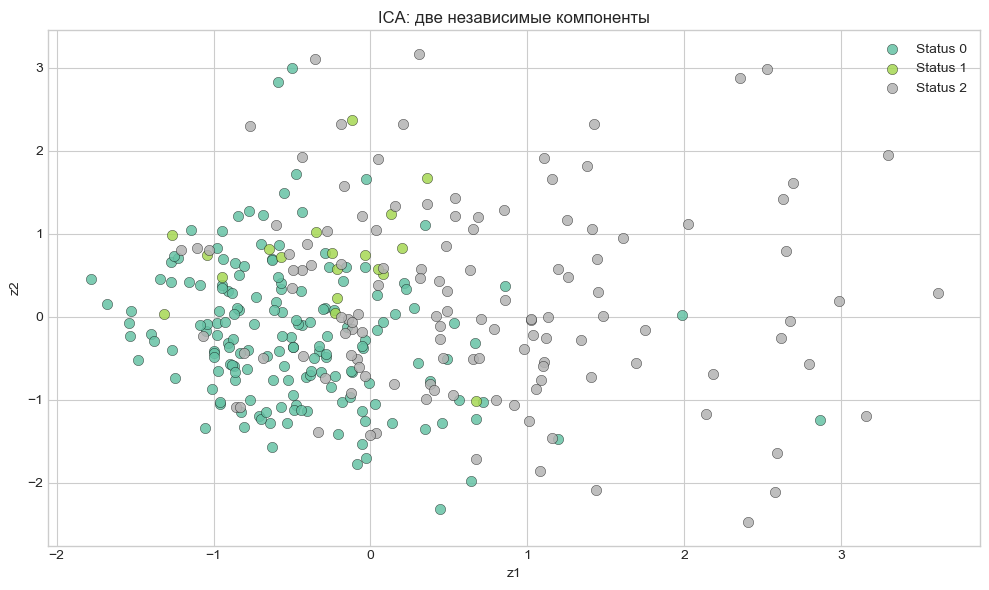

In [61]:
print(f"Количество итераций ICA: {fast_ica.n_iter_}")
plot_embedding(
    X_ica,
    y,
    "ICA: две независимые компоненты",
)

# Нелинейные методы уменьшения размерности

### Kernel PCA

In [62]:
from sklearn.decomposition import KernelPCA

rbf_pca = KernelPCA(n_components=2, kernel="rbf", gamma=0.05, random_state=42)
X_kpca = rbf_pca.fit_transform(X)

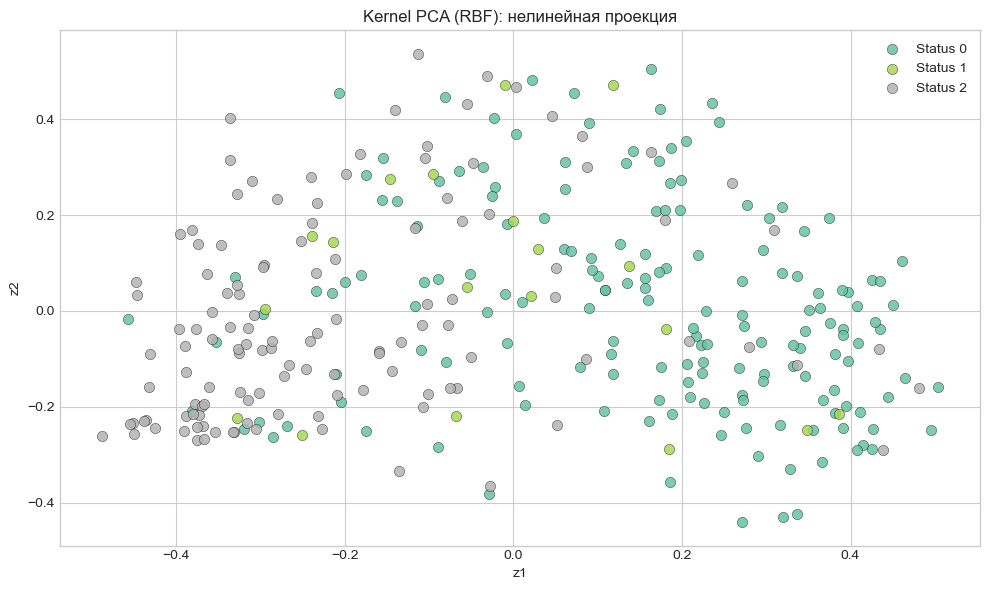

In [63]:
plot_embedding(
    X_kpca,
    y,
    "Kernel PCA (RBF): нелинейная проекция",
)

### tSNE

In [64]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42,
    max_iter=1000,
)
X_tsne = tsne.fit_transform(X)

In [65]:
print("Исходная размерность X:", X.shape)
print("Размерность после t-SNE:", X_tsne.shape)
print("Дивергенция Кульбака-Лейблера после оптимизации:", round(float(tsne.kl_divergence_), 4))
print("Количество итераций:", tsne.n_iter_)


Исходная размерность X: (312, 19)
Размерность после t-SNE: (312, 2)
Дивергенция Кульбака-Лейблера после оптимизации: 0.7624
Количество итераций: 999


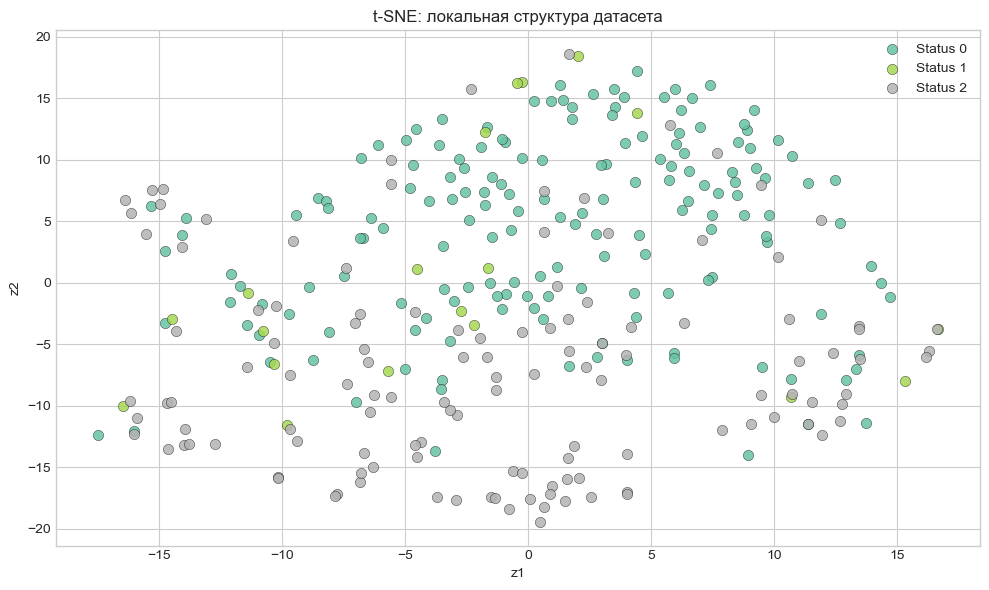

In [66]:
plot_embedding(
    X_tsne,
    y,
    "t-SNE: локальная структура датасета",
)

## Сравнение методов уменьшения размерности

Чтобы не опираться только на визуальное впечатление от графиков:

- silhouette_by_status показывает насколько хорошо в двумерной проекции разделяются реальные значения Status
- trustworthiness показывает насколько хорошо 2D-представление сохраняет локальное соседство исходных многомерных данных

In [67]:
from sklearn.manifold import trustworthiness
from sklearn.metrics import silhouette_score

embedding_summary = pd.DataFrame([
    {
        "method": "PCA",
        "silhouette_by_status": silhouette_score(X_pca, y),
        "trustworthiness": trustworthiness(X, X_pca, n_neighbors=10),
    },
    {
        "method": "ICA",
        "silhouette_by_status": silhouette_score(X_ica, y),
        "trustworthiness": trustworthiness(X, X_ica, n_neighbors=10),
    },
    {
        "method": "Kernel PCA",
        "silhouette_by_status": silhouette_score(X_kpca, y),
        "trustworthiness": trustworthiness(X, X_kpca, n_neighbors=10),
    },
    {
        "method": "t-SNE",
        "silhouette_by_status": silhouette_score(X_tsne, y),
        "trustworthiness": trustworthiness(X, X_tsne, n_neighbors=10),
    },
])

display(embedding_summary.round(4))

,method,silhouette_by_status,trustworthiness
0,PCA,0.0152,0.7802
1,ICA,0.0041,0.7805
2,Kernel PCA,0.0800,0.7166
3,t-SNE,0.0974,0.9249


По результатам сравнения методы **сработали по-разному**.

- Для визуализации и сохранения локальной структуры лучше всего сработал t-SNE: у него самая высокая trustworthiness, то есть соседи в исходном пространстве лучше всего сохраняются в 2D
- Для жёсткого разделения классов Status ни один метод не дал сильного эффекта: значения silhouette_by_status остаются низкими, значит между классами есть заметное перекрытие
- PCA и ICA полезны как базовые линейные проекции, но не дают чёткого распада на три отдельные группы
- Kernel PCA даёт немного более контрастную нелинейную картину, но по сохранению локальной структуры уступает t-SNE

# Поиск выбросов. DBSCAN

DBSCAN для кластеризации и поиска выбросов. Модель обучается на стандартизованных признаках, а визуализация выполняется на плоскости первых двух главных компонент

## DBSCAN для кластеризации

In [68]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, v_measure_score

In [69]:
dbscan_cluster1 = DBSCAN(eps=3.2, min_samples=5)
dbscan_cluster1.fit(X)
cluster_labels = dbscan_cluster1.labels_

In [83]:
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = int(np.sum(cluster_labels == -1))

print("Оценочное количество кластеров:", N_clus)
print("Оценочное количество шумовых точек:", n_noise)

print("v_measure =", round(float(v_measure_score(y, cluster_labels)), 4))

mask = cluster_labels != -1
print("silhouette_score =", round(float(silhouette_score(X[mask], cluster_labels[mask])), 4))


Оценочное количество кластеров: 2
Оценочное количество шумовых точек: 100
v_measure = 0.1851
silhouette_score = 0.2089


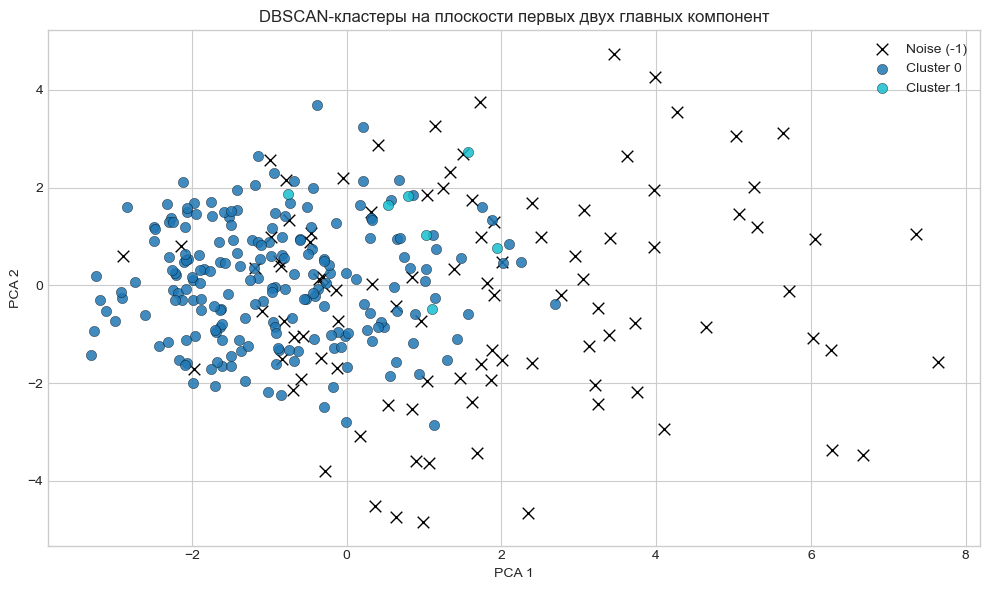

In [72]:
plot_clusters_projection(
    X_pca,
    cluster_labels,
    "DBSCAN-кластеры на плоскости первых двух главных компонент",
)

Чтобы подобрать eps, построим график средних расстояний до ближайших соседей

In [73]:
from sklearn.neighbors import NearestNeighbors

min_samples = 5
knn = NearestNeighbors(n_neighbors=min_samples, metric="euclidean")
knn.fit(X)

dists, inds = knn.kneighbors(X)
dists_ar = dists[:, 1:min_samples].mean(axis=1)
dists_ar.sort()

In [74]:
import sklearn
print(sorted(sklearn.metrics.pairwise.distance_metrics().keys()))

['cityblock', 'cosine', 'euclidean', 'haversine', 'l1', 'l2', 'manhattan', 'nan_euclidean', 'precomputed']


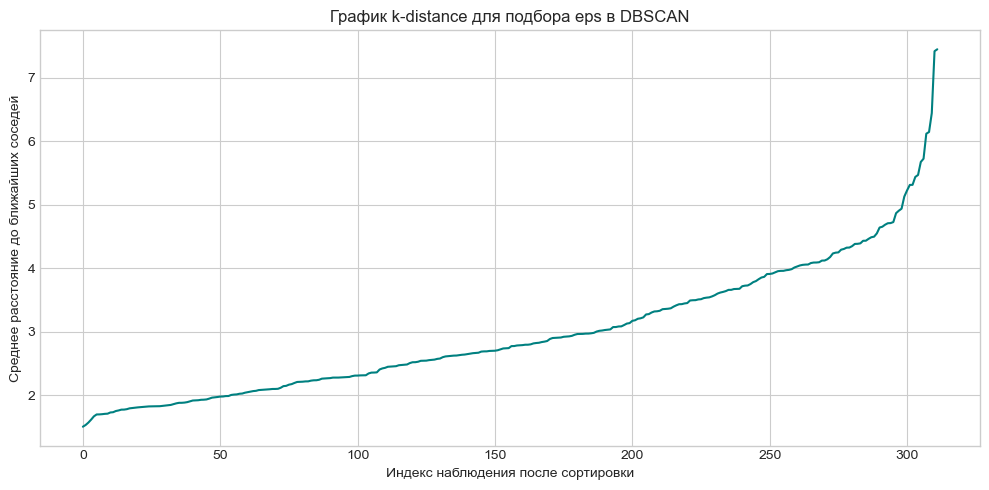

In [75]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(dists_ar)), dists_ar, color="teal")
plt.xlabel("Индекс наблюдения после сортировки")
plt.ylabel("Среднее расстояние до ближайших соседей")
plt.title("График k-distance для подбора eps в DBSCAN")
plt.tight_layout()
plt.show()

Для этого датасета точка перегиба находится примерно в диапазоне `3.0-3.3`, поэтому в дальнейшем используем `eps = 3.2` и `min_samples = 5`.

## DBSCAN для определения выбросов

In [76]:
dbscan = DBSCAN(eps=3.2, min_samples=min_samples)
print(dbscan)

DBSCAN(eps=3.2)


In [77]:
pred = dbscan.fit_predict(X)

In [78]:
labels = dbscan.labels_
N_clus = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = int(np.sum(labels == -1))

print("Оценочное количество кластеров:", N_clus)
print("Оценочное количество шумовых точек:", n_noise)
print("v_measure =", round(float(v_measure_score(y, labels)), 4))

Оценочное количество кластеров: 2
Оценочное количество шумовых точек: 100
v_measure = 0.1851


In [79]:
anom_index = np.where(pred == -1)[0]
anomalies = dataset.iloc[anom_index].copy()

print(f"Найдено {len(anom_index)} потенциальных выбросов.")
display(anomalies[["ID", "Status", "N_Days", "Bilirubin", "Albumin", "Copper", "Stage"]].head(10))

Найдено 100 потенциальных выбросов.


,ID,Status,N_Days,Bilirubin,Albumin,Copper,Stage
0,1,2.0,400,14.5,2.60,156.0,4.0
1,2,0.0,4500,1.1,4.14,54.0,3.0
2,3,2.0,1012,1.4,3.48,210.0,4.0
3,4,2.0,1925,1.8,2.54,64.0,4.0
9,10,2.0,51,12.6,2.74,140.0,4.0
13,14,2.0,1217,0.8,2.27,43.0,4.0
14,15,2.0,3584,0.8,3.87,173.0,3.0
17,18,2.0,131,11.4,2.80,588.0,4.0
20,21,0.0,3445,0.6,3.83,41.0,4.0
21,22,2.0,673,3.4,3.63,464.0,4.0


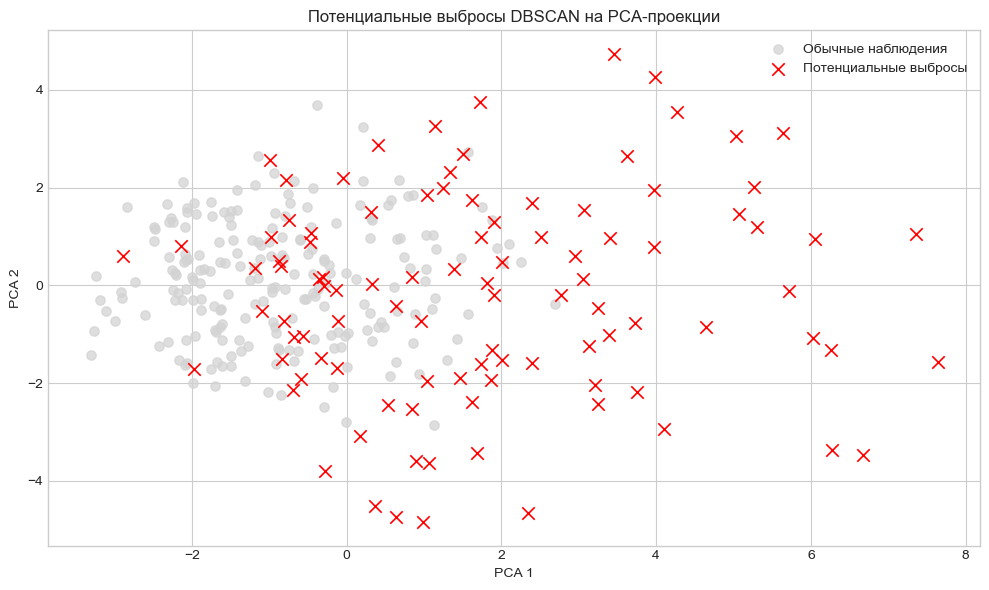

In [80]:
plot_anomalies_projection(
    X_pca,
    pred == -1,
    "Потенциальные выбросы DBSCAN на PCA-проекции",
)

## Интерпретация результата DBSCAN

Посмотрим как найденные кластеры и аномалии соотносятся с исходной колонкой Status

In [81]:
cluster_crosstab = pd.crosstab(
    pd.Series(y, name="Status"),
    pd.Series(cluster_labels, name="DBSCAN_cluster"),
)

anomaly_crosstab = pd.crosstab(
    pd.Series(y, name="Status"),
    pd.Series(pred == -1, name="is_anomaly"),
)

display(cluster_crosstab)
display(anomaly_crosstab)

DBSCAN_cluster,-1,0,1
Status,,,
0,19,147,2
1,4,14,1
2,77,44,4


is_anomaly,False,True
Status,,
0,149,19
1,15,4
2,48,77


Интерпретация здесь такая:

- Для задачи кластеризации по Status метод сработал так себе: DBSCAN выделил 2 плотных кластера и 100 шумовых точек, а не 3 устойчивые группы под значения Status
- Значение v_measure низкое, значит разбиение DBSCAN слабо совпадает с исходной разметкой Status
- Зато для поиска аномалий результат выглядит осмысленно: большинство наблюдений со Status = 2 часто попадают в шум, то есть алгоритм действительно выделяет более нетипичные и неоднородные медицинские профили

# Выводы

1. Все рассмотренные методы технически сработали: для датасета построены двумерные представления и визуализации, а также выполнен поиск выбросов.
2. Если оценивать методы как инструмент визуализации, то лучший результат дал t-SNE: он лучше остальных сохраняет локальное соседство объектов и показывает наиболее читаемую структуру данных.
3. Если оценивать методы как инструмент разделения классов Status, то результат умеренный: классы заметно перекрываются, поэтому ни PCA, ни ICA, ни Kernel PCA, ни t-SNE не образуют идеально разделённые группы.
4. PCA оказался полезен для общей ориентации в данных
5. ICA и Kernel PCA тоже выявляют структуру, но не дают явного качественного преимущества над t-SNE для данного набора.
6. DBSCAN слабо сработал как алгоритм кластеризации классов, потому что нашёл 2 кластера и 100 шумовых наблюдений при низком совпадении с Status.
7. DBSCAN частично сработал как метод поиска выбросов: он хорошо выделяет нетипичные случаи, и особенно часто в шум попадают объекты со Status = 2, что согласуется с более тяжёлыми или нестандартными состояниями пациентов.
8. Размерность исходных данных была успешно снижена с (312, 19) до (312, 2) с помощью методов PCA, ICA, Kernel PCA и t-SNE. Это позволило получить удобное двумерное представление данных для визуализации. Однако полная структура данных при таком сжатии не сохраняется: например, первые две компоненты PCA объясняют только около 35.4% дисперсии. Следовательно, понижение размерности в работе выполнено успешно, но двух измерений недостаточно для полного сохранения всей информации